In [11]:
import h5py
import numpy as np
import os
import matplotlib.pyplot as plt
import os
import tensorflow as tf



########## TODO
# random forrest

#XG boost 
# NN
#train on minorized data

In [12]:
# minorized reference
with h5py.File('/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5', 'r') as file:
    #print("Keys: %s" % file.keys())
    ref_d = file['density'][:]
#print(ref_d)
print(ref_d.shape)




(64, 64, 64)


In [13]:
def D_JS(p1,p2,tol=1e-16):
    p1=p1/np.sum(p1)
    p2=p2/np.sum(p2)
    pm = (p1+p2)/2
    p1_nonzero = np.abs(p1)>tol
    p2_nonzero = np.abs(p2)>tol
    p1  = np.abs(p1[p1_nonzero])
    pm1 = np.abs(pm[p1_nonzero])
    p2  = np.abs(p2[p2_nonzero])
    pm2 = np.abs(pm[p2_nonzero])
    d = .5*( (p1*np.log(p1/pm1)).sum() + (p2*np.log(p2/pm2)).sum() )
    d /= np.log(2) # normalize to max of 1
    return d

In [14]:
data = np.load("/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/DFT_dat_lev2436000_sample_training_data.npz")


In [15]:
print(data['x_train'].shape)

(1000, 64, 64, 64)


In [16]:
x_train = data['x_train']
x_val   = data['x_val']
y_train = data['y_train']
y_val   = data['y_val']

n_samples = data["total_samples"]


data = 0


In [17]:
print(x_train.shape)

(1000, 64, 64, 64)


In [18]:
with h5py.File('/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0000655360.h5', 'r') as file:
    #print("Keys: %s" % file.keys())
    test_d = file['density'][:]

In [19]:
print("here")

here


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import joblib  # <-- for saving scikit-learn models
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# -----------------------
# Utilities
# -----------------------
def flatten_samples(samples):
    samples = np.asarray(samples)
    if len(samples.shape) == 1:
        return samples.reshape(1, -1)  # single 1D sample → (1, n_features)
    elif len(samples.shape) > 2:
        return samples.reshape(samples.shape[0], -1)  # keep n_samples
    return samples  # already 2D

def apply_fft(samples):
    samples = np.asarray(samples)
    fft_samples = np.fft.fftn(samples, axes=tuple(range(1, samples.ndim)))
    return np.abs(fft_samples).reshape(samples.shape[0], -1) if len(samples.shape) > 1 else np.abs(fft_samples).reshape(1, -1)

# -----------------------
# Random Forest
# -----------------------
def rf_denoiser(train_x, train_y, test_x, model_path='rf_model.joblib', use_fft=False):
    train_x = flatten_samples(train_x)
    train_y = flatten_samples(train_y)
    test_x = flatten_samples(test_x)

    if use_fft:
        train_x = np.fft.fft(train_x, axis=1).real
        test_x = np.fft.fft(test_x, axis=1).real

    rf = RandomForestRegressor(
    n_estimators=50,      # can increase once speed improves
    max_depth=10,         # limit tree depth
    max_features=0.25,    # only consider 25% of features per split
    n_jobs=-1,
    random_state=42)
    rf.fit(train_x, train_y)

    # Save trained model
    joblib.dump(rf, model_path)
    print(f"Saved RandomForest model to {model_path}")

    pred_flat = rf.predict(test_x)
    return pred_flat.reshape(test_x.shape[1:])

# -----------------------
# Dense Neural Network
# -----------------------
def nn_denoiser(train_x, train_y, test_x, hidden_units=[256, 128], 
                epochs=50, batch_size=32, model_path='nn_model.h5'):
    X_train = flatten_samples(train_x)
    Y_train = flatten_samples(train_y)
    X_test = flatten_samples(test_x)

    model = models.Sequential([
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(hidden_units[0], activation='relu'),
        layers.Dense(hidden_units[1], activation='relu'),
        layers.Dense(Y_train.shape[1], activation='linear')
    ])

    model.compile(optimizer='adam', loss='mse')
    early_stop = callbacks.EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
    model.fit(X_train, Y_train, epochs=epochs, batch_size=batch_size, verbose=0, callbacks=[early_stop])
    model.save(model_path)
    return model.predict(X_test)
# -----------------------
# Example usage with user-supplied data
# -----------------------
# x_train, y_train, x_val, y_val, test_d, ref_d
# Make sure these are NumPy arrays
# Example shapes: 
#   1D: (64,)
#   2D: (64, 64)
#   3D: (64, 64, 64)
#   Multiple samples: (n_samples, 64) or (n_samples, 64, 64) etc.

print("DFT norm =", np.linalg.norm(ref_d))

# Random Forest (without FFT)
rf_pred = rf_denoiser(x_train, y_train, test_d.reshape((1, 64**3)), use_fft=False, model_path='rf_model_3d.joblib')
print("RF_done")
print(np.linalg.norm(rf_pred))

# Random Forest (with FFT)
rf_fft_pred = rf_denoiser(x_train, y_train, test_d.reshape((1, 64**3)), use_fft=True, model_path='rf_fft_model_3d.joblib')
print("RF_fft_done")
print(np.linalg.norm(rf_fft_pred))

# Dense Neural Network
nn_pred = nn_denoiser(x_train, y_train, test_d.reshape((1, 64**3
                                                       )), model_path='nn_model_3d.h5')
print("NN_done")
print(np.linalg.norm(nn_pred))


DFT norm = 0.020995354358128854


In [ ]:
print("here")


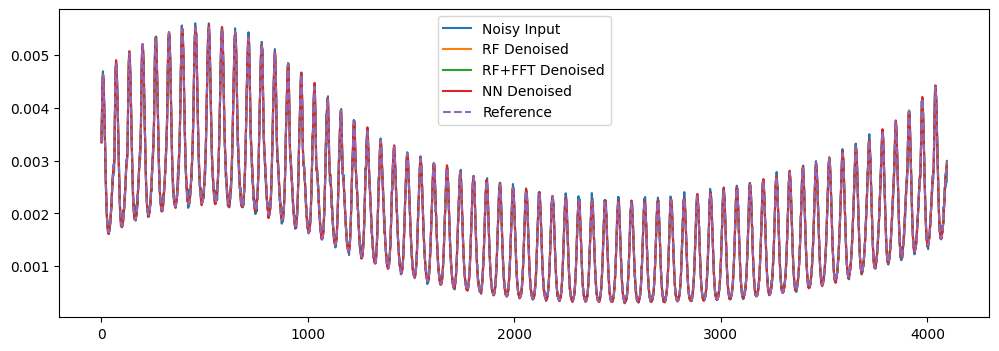

In [20]:
# -----------------------
# Visualization (1D example; adapt for 2D/3D)
# -----------------------
plt.figure(figsize=(12,4))
plt.plot(test_d.ravel(), label='Noisy Input')
plt.plot(rf_pred.ravel(), label='RF Denoised')
plt.plot(rf_fft_pred.ravel(), label='RF+FFT Denoised')
plt.plot(nn_pred.ravel(), label='NN Denoised')
#plt.plot(xgb_pred.ravel(), label='XGBoost Denoised')
plt.plot(ref_d.ravel(), '--', label='Reference')
plt.legend()
plt.show()


In [23]:
import numpy as np
import joblib
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
import os

# ============================
# Utility functions
# ============================

def flatten_data(data):
    """Flatten each sample to 1D (n_samples, n_features)."""
    data = np.asarray(data)
    if data.ndim == 1:
        return data.reshape(1, -1)
    elif data.ndim > 2:
        return data.reshape(data.shape[0], -1)
    return data

# ============================
# 1. Linear Regression
# ============================

def linear_regressor(train_x, train_y, val_x=None, test_x=None, model_path="linear_model.joblib"):
    X_train = flatten_data(train_x)
    Y_train = flatten_data(train_y)

    # Train & save model
    model = LinearRegression()
    model.fit(X_train, Y_train)
    joblib.dump(model, model_path)
    print(f"Saved Linear Regression model to {model_path}")

    preds = {}
    preds["train"] = model.predict(X_train).reshape(train_y.shape)
    if val_x is not None:
        preds["val"] = model.predict(flatten_data(val_x)).reshape(val_x.shape)
    if test_x is not None:
        preds["test"] = model.predict(flatten_data(test_x)).reshape(test_x.shape)
    return preds

# ============================
# 2. Linear Regression + PCA
# ============================

def linear_regressor_pca(train_x, train_y, val_x=None, test_x=None, n_components=50,
                         model_path="linear_pca_model.joblib",
                         scaler_path="scaler.joblib",
                         pca_path="pca.joblib"):
    X_train = flatten_data(train_x)
    Y_train = flatten_data(train_y)
    X_val   = flatten_data(val_x)   if val_x is not None else None
    X_test  = flatten_data(test_x)  if test_x is not None else None

    # Scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled   = scaler.transform(X_val)   if X_val is not None else None
    X_test_scaled  = scaler.transform(X_test)  if X_test is not None else None

    # Cap PCA components
    n_components = min(n_components, X_train_scaled.shape[0], X_train_scaled.shape[1])

    # PCA
    pca = PCA(n_components=n_components)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca   = pca.transform(X_val_scaled)   if X_val_scaled is not None else None
    X_test_pca  = pca.transform(X_test_scaled)  if X_test_scaled is not None else None

    # Linear model
    model = LinearRegression()
    model.fit(X_train_pca, Y_train)

    # Save all components
    joblib.dump(model, model_path)
    joblib.dump(pca, pca_path)
    joblib.dump(scaler, scaler_path)
    print(f"Saved PCA Linear Regression model to {model_path}")
    print(f"Saved PCA to {pca_path} and Scaler to {scaler_path}")

    preds = {}
    preds["train"] = model.predict(X_train_pca).reshape(train_y.shape)
    if X_val_pca is not None:
        preds["val"] = model.predict(X_val_pca).reshape(val_x.shape)
    if X_test_pca is not None:
        preds["test"] = model.predict(X_test_pca).reshape(test_x.shape)
    return preds



# ============================
# Example usage
# ============================

print(x_train.shape)
print(x_val.shape)
print(y_train.shape)
print(y_val.shape)
print(test_d.reshape((1, 64**2)).shape)

print("ref norm = ", np.linalg.norm(ref_d))

# Linear regression
preds_lin = linear_regressor(x_train, y_train, x_val, test_d.reshape((1, 64**2)), model_path="linear_model.joblib")
print("Linear regression done:", np.linalg.norm(preds_lin["test"]))

# Linear regression with PCA
preds_pca = linear_regressor_pca(x_train, y_train, x_val, test_d.reshape((1, 64**2)), n_components=5)
print("Linear regression (PCA) done:", np.linalg.norm(preds_pca["test"]))

# Simple neural net (optional)
# preds_nn = nn_regressor(x_train, y_train, x_val, test_d.reshape((1, 64)), epochs=10)
# print("NN done:", np.linalg.norm(preds_nn["test"]))


(1000, 64, 64)
(200, 64, 64)
(1000, 64, 64)
(200, 64, 64)
(1, 4096)
ref norm =  0.14656592070668206
Saved Linear Regression model to linear_model.joblib
Linear regression done: 0.14656576978218128
Saved PCA Linear Regression model to linear_pca_model.joblib
Saved PCA to pca.joblib and Scaler to scaler.joblib
Linear regression (PCA) done: 0.14656644603173993


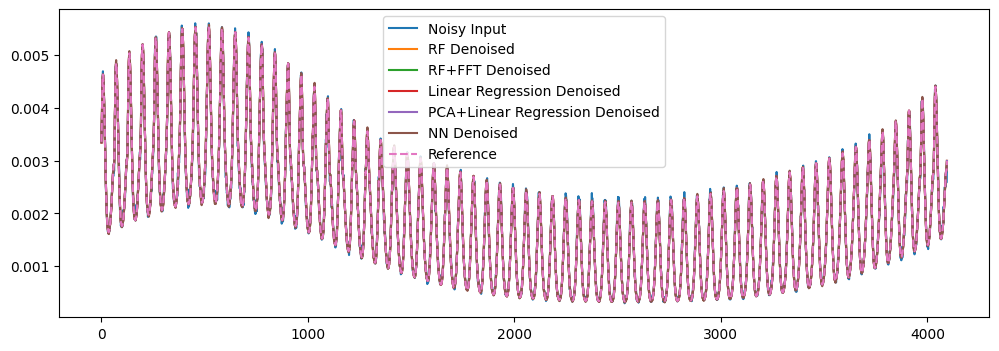

In [24]:
# -----------------------
# Visualization (1D example; adapt for 2D/3D)
# -----------------------
plt.figure(figsize=(12,4))
plt.plot(test_d.ravel(), label='Noisy Input')
plt.plot(rf_pred.ravel(), label='RF Denoised')
plt.plot(rf_fft_pred.ravel(), label='RF+FFT Denoised')

# Add our new methods
plt.plot(preds_lin["test"].ravel(), label='Linear Regression Denoised')
plt.plot(preds_pca["test"].ravel(), label='PCA+Linear Regression Denoised')
plt.plot(nn_pred.ravel(), label='NN Denoised')

plt.plot(ref_d.ravel(), '--', label='Reference')
plt.legend()
plt.show()

In [26]:
import joblib
from tensorflow.keras.models import load_model

rf_model = joblib.load('rf_model.joblib')
rf_fft_model = joblib.load('rf_fft_model.joblib')
nn_model = load_model('nn_model.h5', compile=False)


# Example inference
rf_pred = rf_model.predict(flatten_samples(test_d.reshape(1, -1)))
rf_fft_pred = rf_fft_model.predict(flatten_samples(test_d.reshape(1, -1)))
nn_pred = nn_model.predict(flatten_samples(test_d.reshape(1, -1)))


# Load models
linear_model = joblib.load("linear_model.joblib")
pca_model = joblib.load("linear_pca_model.joblib")
scaler = joblib.load("scaler.joblib")
pca = joblib.load("pca.joblib")

# Example inference with PCA model
X_test = flatten_data(test_d.reshape((1, 64**2)))
X_test_scaled = scaler.transform(X_test)
X_test_pca = pca.transform(X_test_scaled)
pca_pred = pca_model.predict(X_test_pca)

print("done loading")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
done loading


Found 33 noisy files.


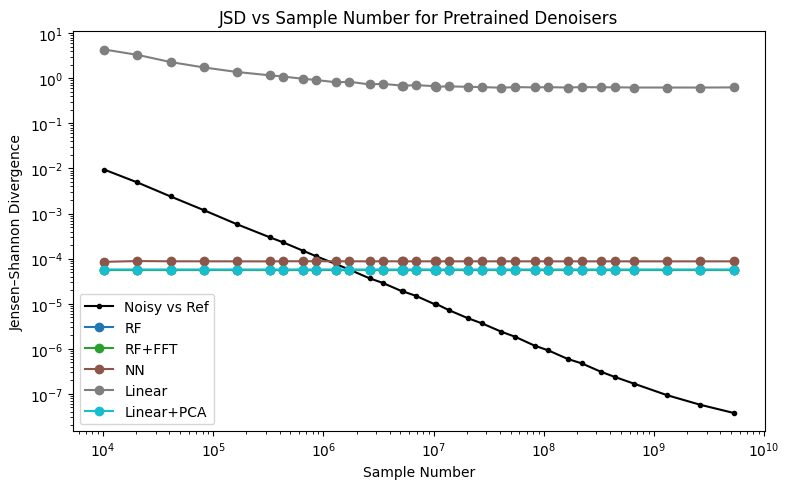

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os, glob, re
from tensorflow.keras.models import load_model
from sklearn.utils.validation import check_is_fitted

# ===========================================================
# Utilities
# ===========================================================
def minorize_data(data):
    """Sum over axes 1 and 2 → reduces (A,B,C) to (A,)"""
    return np.sum(data, axis=(2))

def D_JS(p1,p2,tol=1e-16):
    p1=p1/np.sum(p1)
    p2=p2/np.sum(p2)
    pm = (p1+p2)/2
    p1_nonzero = np.abs(p1)>tol
    p2_nonzero = np.abs(p2)>tol
    p1  = np.abs(p1[p1_nonzero])
    pm1 = np.abs(pm[p1_nonzero])
    p2  = np.abs(p2[p2_nonzero])
    pm2 = np.abs(pm[p2_nonzero])
    d = .5*( (p1*np.log(p1/pm1)).sum() + (p2*np.log(p2/pm2)).sum() )
    d /= np.log(2) # normalize to max of 1
    return d

# ===========================================================
# Load Datasets
# ===========================================================
base_dir = "/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2"
ref_path = os.path.join(base_dir, "density_tot_ref_mean.h5")
noisy_files = sorted(glob.glob(os.path.join(base_dir, "density_tot_vmc_mean*.h5")))

print(f"Found {len(noisy_files)} noisy files.")

with h5py.File(ref_path, 'r') as f:
    ref_d_full = f['density'][:]
ref_minor = minorize_data(ref_d_full)

noisy_data = []
sample_nums = []
for path in noisy_files:
    m = re.search(r"(\d+)\.h5$", path)
    if not m:
        continue
    idx = int(m.group(1))
    with h5py.File(path, 'r') as f:
        arr = f['density'][:]
    noisy_data.append(minorize_data(arr))
    sample_nums.append(idx)

noisy_data = np.array(noisy_data)
sample_nums = np.array(sample_nums)

# ===========================================================
# Load Models (Pretrained, Already in Runtime)
# ===========================================================
rf_model       # already loaded
rf_fft_model   # already loaded
nn_model       # already loaded
linear_model = joblib.load("linear_model.joblib")
pca_model = joblib.load("linear_pca_model.joblib")
scaler = joblib.load("scaler.joblib")
pca = joblib.load("pca.joblib")

# ===========================================================
# Prediction Helpers
# ===========================================================
def get_pred_rf(model, test_x):
    check_is_fitted(model)
    flat = test_x.reshape(1, -1)
    pred_flat = model.predict(flat)
    return pred_flat.reshape(test_x.shape)

def get_pred_nn(model, test_x):
    flat = test_x.reshape(1, -1)
    pred_flat = model.predict(flat, verbose=0)
    return pred_flat.reshape(test_x.shape)

def get_pred_linear(model, scaler, test_x):
    flat = test_x.reshape(1, -1)
    flat_scaled = scaler.transform(flat)
    pred_flat = model.predict(flat_scaled)
    return pred_flat.reshape(test_x.shape)

def get_pred_linear_pca(model, scaler, pca, test_x):
    flat = test_x.reshape(1, -1)
    flat_scaled = scaler.transform(flat)
    flat_pca = pca.transform(flat_scaled)
    pred_flat = model.predict(flat_pca)
    return pred_flat.reshape(test_x.shape)

# ===========================================================
# Compute Reference JSD (Noisy vs Ref)
# ===========================================================
results_ref = []
for i, sample in enumerate(noisy_data):
    jsd = D_JS(ref_minor, sample)
    results_ref.append((sample_nums[i], jsd))
results_ref = np.array(sorted(results_ref, key=lambda x: x[0]))

# ===========================================================
# Evaluate All Models
# ===========================================================
all_results = {}

# --- RF ---
rf_results = []
for i, sample in enumerate(noisy_data):
    pred = get_pred_rf(rf_model, sample)
    jsd_val = D_JS(ref_minor, pred)
    rf_results.append((sample_nums[i], jsd_val))
all_results["RF"] = np.array(sorted(rf_results, key=lambda x: x[0]))

# --- RF+FFT ---
rf_fft_results = []
for i, sample in enumerate(noisy_data):
    pred = get_pred_rf(rf_fft_model, sample)
    jsd_val = D_JS(ref_minor, pred)
    rf_fft_results.append((sample_nums[i], jsd_val))
all_results["RF+FFT"] = np.array(sorted(rf_fft_results, key=lambda x: x[0]))

# --- NN ---
nn_results = []
for i, sample in enumerate(noisy_data):
    pred = get_pred_nn(nn_model, sample)
    jsd_val = D_JS(ref_minor, pred)
    nn_results.append((sample_nums[i], jsd_val))
all_results["NN"] = np.array(sorted(nn_results, key=lambda x: x[0]))

# --- Linear ---
lin_results = []
for i, sample in enumerate(noisy_data):
    pred = get_pred_linear(linear_model, scaler, sample)
    jsd_val = D_JS(ref_minor, pred)
    lin_results.append((sample_nums[i], jsd_val))
all_results["Linear"] = np.array(sorted(lin_results, key=lambda x: x[0]))

# --- Linear + PCA ---
lin_pca_results = []
for i, sample in enumerate(noisy_data):
    pred = get_pred_linear_pca(pca_model, scaler, pca, sample)
    jsd_val = D_JS(ref_minor, pred)
    lin_pca_results.append((sample_nums[i], jsd_val))
all_results["Linear+PCA"] = np.array(sorted(lin_pca_results, key=lambda x: x[0]))

# ===========================================================
# Plot Results
# ===========================================================
plt.figure(figsize=(8,5))
plt.loglog(results_ref[:,0], results_ref[:,1], 'k.-', label="Noisy vs Ref")

colors = plt.cm.tab10(np.linspace(0, 1, len(all_results)))
for color, (name, data) in zip(colors, all_results.items()):
    plt.loglog(data[:,0], data[:,1], marker='o', linestyle='-', label=name, color=color)

plt.xlabel("Sample Number")
plt.ylabel("Jensen–Shannon Divergence")
plt.title("JSD vs Sample Number for Pretrained Denoisers")
plt.legend()
plt.tight_layout()
plt.show()